In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
tab = pd.read_csv("accuracies/accuracies_cifar_heads_formatted.csv")
tab.sort_values(by='threshold', inplace=True)

In [24]:
tab.columns

Index(['skip_config', 'accuracy_mean', 'accuracy_std', 'threshold',
       'heads_dropped', 'parameters_saved'],
      dtype='object')

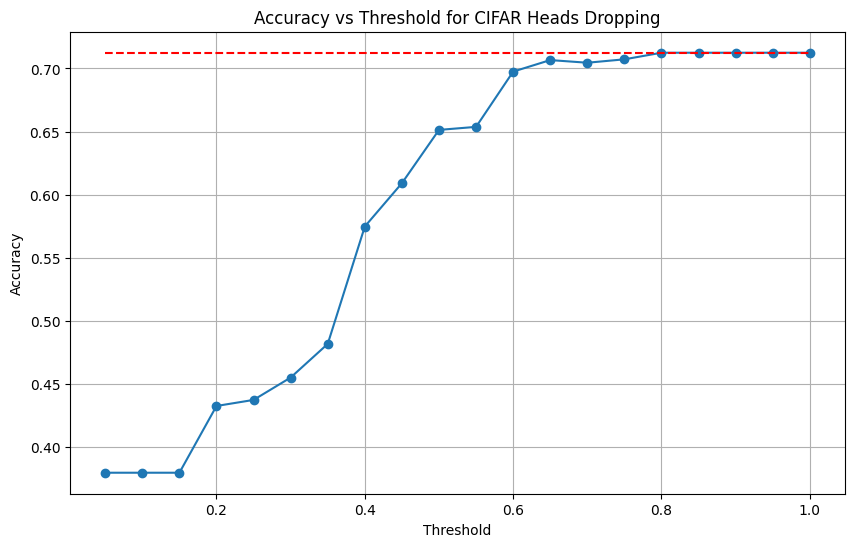

In [23]:
# plot accuracies vs threshold
plt.figure(figsize=(10, 6))
plt.plot(tab['threshold'], tab['accuracy_mean'], marker='o', label='Accuracy')
plt.title('Accuracy vs Threshold for CIFAR Heads Dropping')
plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.hlines(y=tab['accuracy_mean'].max(), xmin=tab['threshold'].min(), xmax=tab['threshold'].max(), colors='r', linestyles='dashed', label='Max Accuracy')
plt.grid()


Text(0.5, 1.0, 'Accuracy and Parameters Count vs Threshold for CIFAR100 Heads Dropping')

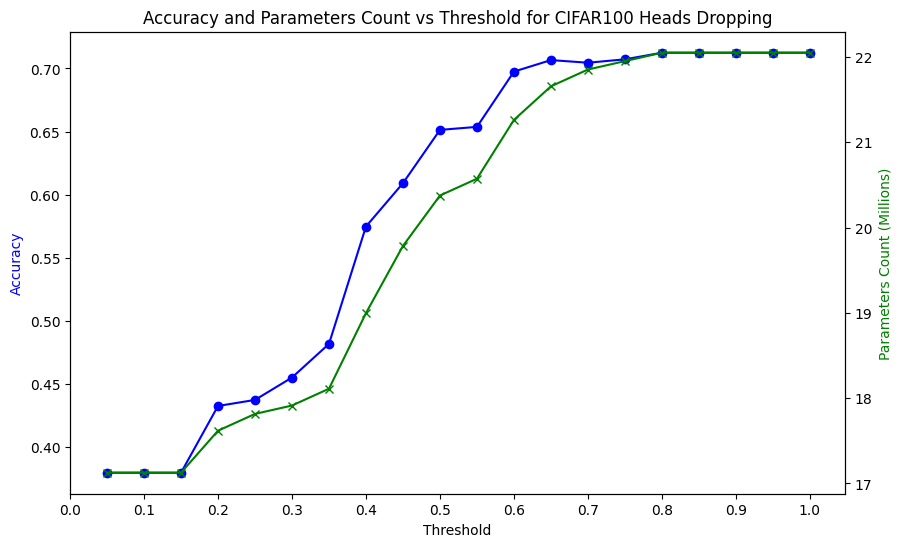

In [37]:
# plot accuracies vs threshold with error bars on one axis and then saved parameters on the other axis
tab['parameters_count'] = tab.apply(lambda row: (22050000 - row['heads_dropped'] * 98496)/1000000, axis=1)

plt.figure(figsize=(10, 6))
# Create a twin axis for the parameters saved
ax1 = plt.gca()
ax2 = ax1.twinx()
ax1.plot(tab['threshold'], tab['accuracy_mean'], marker='o', label='Accuracy', color='b')
ax2.plot(tab['threshold'], tab['parameters_count'], marker='x', label='Parameters Count', color='g')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Accuracy', color='b')
ax2.set_ylabel('Parameters Count (Millions)', color='g')   
ax2.set_xticks(0.1 * np.arange(0, 11))
ax1.set_title('Accuracy and Parameters Count vs Threshold for CIFAR100 Heads Dropping')

In [28]:
tab['parameters_saved']

1     17125200
2     17125200
3     17125200
4     17617680
5     17814672
6     17913168
7     18110160
8     18996624
9     19784592
10    20375568
11    20572560
12    21262032
13    21656016
14    21853008
15    21951504
16    22050000
17    22050000
18    22050000
19    22050000
0     22050000
Name: parameters_saved, dtype: int64